In [2]:
import numpy as np
import pandas as pd
import math, random
import matplotlib.pyplot as plt

Analyzing sequence: GRSTTBASSTTBAGBWSCYACWSC
Sequence length: 24
Degenerate bases found at positions: [2, 3, 6, 8, 9, 12, 15, 16, 17, 19, 22, 23]
Generating multiple resolutions for analysis...

=== RESULTS ===
Sequence used (X): GRSTTBASSTTBAGBWSCYACWSC
Log-likelihood under PSSM: -7.7897476544685
Mean pairwise Hamming (natural_pool): 3.5522033008252065
Mean pairwise Hamming (mutated_from_X): 9.580248937234309
Mean per-position JS divergence (bits): 0.165509925260817
Per-position entropy (bits) mean: 0.46978133339558587

Note: Analysis based on 100 resolutions of degenerate sequence


/tmp/ipykernel_10254/2821393863.py:90: RuntimeWarning: divide by zero encountered in log2
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
/tmp/ipykernel_10254/2821393863.py:90: RuntimeWarning: invalid value encountered in multiply
  ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)


Saved histogram CSV to pssm_pairwise_hamming_hist.csv


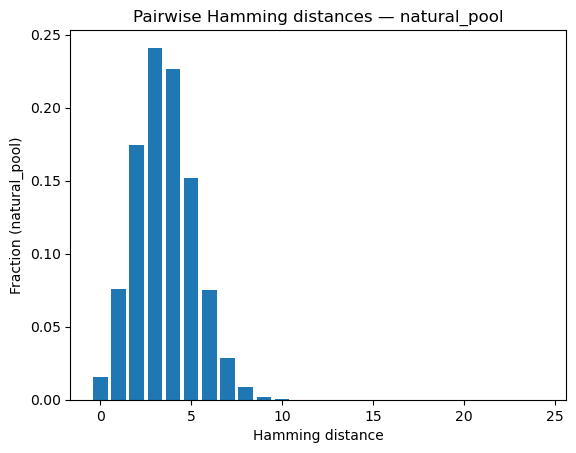

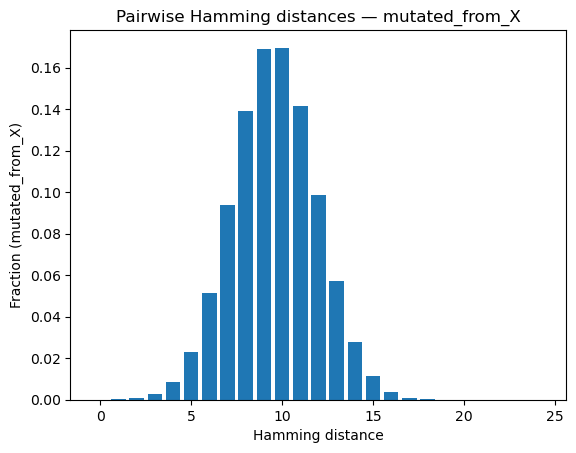

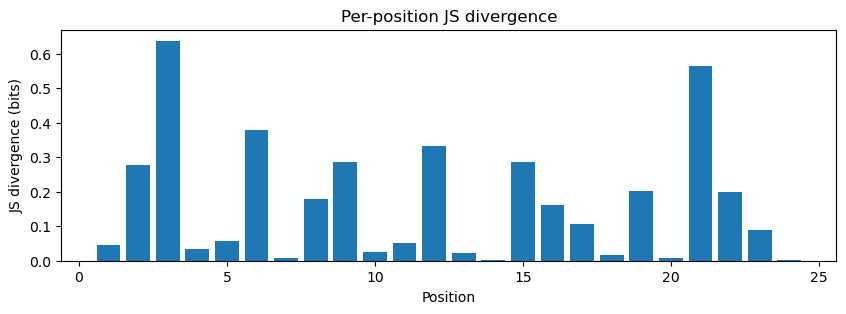


=== DEGENERATE BASE INFORMATION ===
Position 2: 'R' can be ['A', 'G']
Position 3: 'S' can be ['G', 'C']
Position 6: 'B' can be ['C', 'G', 'T']
Position 8: 'S' can be ['G', 'C']
Position 9: 'S' can be ['G', 'C']
Position 12: 'B' can be ['C', 'G', 'T']
Position 15: 'B' can be ['C', 'G', 'T']
Position 16: 'W' can be ['A', 'T']
Position 17: 'S' can be ['G', 'C']
Position 19: 'Y' can be ['C', 'T']
Position 22: 'W' can be ['A', 'T']
Position 23: 'S' can be ['G', 'C']


In [11]:
#CDR_1 VALIDATION DEGENERATE
your_sequence = "GRSTTBASSTTBAGBWSCYACWSC"  # ваша последовательность с вырожденным нуклеотидом B
# Путь к вашему PSSM (тот же, что вы загрузили)
pssm_path = "Downloads/cdr1_nucleotide_frequencies.csv"

# Загрузим PSSM — ожидается формат: строки = A/T/G/C, столбцы = Pos1..Pos24
raw = pd.read_csv(pssm_path)
raw = raw.set_index(raw.columns[0])

# Упорядочим ряды как A,C,G,T (на случай иной капитализации)
row_order = []
for r in ['A','C','G','T']:
    for idx in raw.index:
        if str(idx).upper() == r:
            row_order.append(idx)
            break
raw = raw.loc[row_order]

# Транспонируем к форме (positions x nucleotides)
pssm_df = raw.transpose().reset_index(drop=True)
pssm_df.columns = ['A','C','G','T']
pssm_df = pssm_df.astype(float)
pssm_df.index = range(1, 1 + pssm_df.shape[0])

# Нормализация строк (на случай, если в файле counts)
prob_mat = pssm_df[['A','C','G','T']].to_numpy()
row_sums = prob_mat.sum(axis=1, keepdims=True)
prob_mat = np.divide(prob_mat, row_sums, where=(row_sums!=0))

nt_index = {'A':0,'C':1,'G':2,'T':3}

# Словарь вырожденных нуклеотидов IUPAC
degenerate_bases = {
    'R': ['A', 'G'],  # Purine
    'Y': ['C', 'T'],  # Pyrimidine
    'S': ['G', 'C'],  # Strong
    'W': ['A', 'T'],  # Weak
    'K': ['G', 'T'],  # Keto
    'M': ['A', 'C'],  # Amino
    'B': ['C', 'G', 'T'],  # Not A
    'D': ['A', 'G', 'T'],  # Not C
    'H': ['A', 'C', 'T'],  # Not G
    'V': ['A', 'C', 'G'],  # Not T
    'N': ['A', 'C', 'G', 'T'],  # Any
}

def validate_seq(seq, L):
    seq = seq.upper().strip()
    if len(seq) != L:
        raise ValueError(f"Sequence length {len(seq)} != expected {L}.")
    valid_chars = set('ACGT') | set(degenerate_bases.keys())
    if any(ch not in valid_chars for ch in seq):
        raise ValueError(f"Sequence contains invalid characters. Valid: ACGT{''.join(degenerate_bases.keys())}")
    return seq

def expand_degenerate_base(base):
    """Раскрывает вырожденный нуклеотид в список возможных стандартных нуклеотидов"""
    base = base.upper()
    if base in 'ACGT':
        return [base]
    elif base in degenerate_bases:
        return degenerate_bases[base]
    else:
        raise ValueError(f"Unknown nucleotide: {base}")

def seq_log_likelihood(seq):
    seq = validate_seq(seq, prob_mat.shape[0])
    ll = 0.0
    for i, ch in enumerate(seq):
        possible_bases = expand_degenerate_base(ch)
        # Для вырожденных позиций используем сумму вероятностей всех возможных нуклеотидов
        if len(possible_bases) > 1:
            p_sum = sum(prob_mat[i, nt_index[b]] for b in possible_bases)
            if p_sum <= 0:
                ll += -1e9
            else:
                ll += math.log(p_sum)
        else:
            # Для стандартных нуклеотидов - обычный расчет
            p = prob_mat[i, nt_index[ch]]
            if p <= 0:
                ll += -1e9
            else:
                ll += math.log(p)
    return ll

def per_position_entropy(mat=None):
    if mat is None:
        mat = prob_mat
    ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
    return ent

def sample_from_pssm(n_samples=2000):
    L = prob_mat.shape[0]
    samples = []
    for _ in range(n_samples):
        seq = []
        for i in range(L):
            seq.append(random.choices(['A','C','G','T'], weights=prob_mat[i], k=1)[0])
        samples.append(''.join(seq))
    return samples

def mutate_sequence_pool(X, n_samples=2000, mean_mutations=3.0):
    L = prob_mat.shape[0]
    X = validate_seq(X, L)
    samples = []
    for _ in range(n_samples):
        k = int(np.random.poisson(mean_mutations))
        k = min(max(0, k), L)
        seq = list(X)
        if k > 0:
            # Выбираем позиции для мутации (только стандартные нуклеотиды могут мутировать)
            standard_positions = [pos for pos in range(L) if seq[pos] in 'ACGT']
            if standard_positions:
                k = min(k, len(standard_positions))
                positions = random.sample(standard_positions, k)
                for pos in positions:
                    probs = prob_mat[pos].copy()
                    orig_idx = nt_index[seq[pos]]
                    probs[orig_idx] = 0.0
                    s = probs.sum()
                    if s <= 0:
                        choices = [b for b in ['A','C','G','T'] if b != seq[pos]]
                        seq[pos] = random.choice(choices)
                    else:
                        probs = probs / s
                        seq[pos] = random.choices(['A','C','G','T'], weights=probs, k=1)[0]
        samples.append(''.join(seq))
    return samples

def resolve_degenerate_sequence(seq, n_resolutions=100):
    """Генерирует несколько конкретных последовательностей из вырожденной"""
    L = len(seq)
    resolutions = []
    for _ in range(n_resolutions):
        resolved_seq = []
        for base in seq:
            if base in 'ACGT':
                resolved_seq.append(base)
            else:
                possible_bases = expand_degenerate_base(base)
                resolved_seq.append(random.choice(possible_bases))
        resolutions.append(''.join(resolved_seq))
    return resolutions

def pairwise_hamming_distance_matrix(seqs):
    n = len(seqs)
    arr = np.array([list(s) for s in seqs])
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            d = np.count_nonzero(arr[i] != arr[j])
            dists.append(d)
    return np.array(dists)

def per_position_freqs(seqs):
    L = len(seqs[0])
    freqs = np.zeros((L,4))
    for s in seqs:
        for i,ch in enumerate(s):
            freqs[i, ['A','C','G','T'].index(ch)] += 1
    freqs = freqs / freqs.sum(axis=1, keepdims=True)
    return freqs

def js_divergence(p, q):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.where(a>0, a, 1e-12)
        b = np.where(b>0, b, 1e-12)
        return np.sum(a * np.log2(a/b))
    L = p.shape[0]
    js = np.array([0.5*(kl(p[i], m[i]) + kl(q[i], m[i])) for i in range(L)])
    return js, js.mean()

def analyze_sequence(X, N=4000, mean_mutations=3.0, n_degenerate_resolutions=100):
    """
    Анализирует последовательность X (может содержать вырожденные нуклеотиды) относительно PSSM
    """
    
    # Валидация последовательности
    X = validate_seq(X, prob_mat.shape[0])
    
    print(f"Analyzing sequence: {X}")
    print(f"Sequence length: {len(X)}")
    
    # Проверяем наличие вырожденных нуклеотидов
    degenerate_positions = [i for i, base in enumerate(X) if base not in 'ACGT']
    if degenerate_positions:
        print(f"Degenerate bases found at positions: {[pos+1 for pos in degenerate_positions]}")
        print("Generating multiple resolutions for analysis...")
    
    # Генерация пулов последовательностей
    natural_pool = sample_from_pssm(n_samples=N)
    
    # Для вырожденных последовательностей генерируем несколько конкретных вариантов
    if degenerate_positions:
        # Анализ для нескольких разрешений вырожденной последовательности
        resolved_sequences = resolve_degenerate_sequence(X, n_resolutions=n_degenerate_resolutions)
        all_mutated_pools = []
        
        for resolved_seq in resolved_sequences:
            mutated_pool = mutate_sequence_pool(resolved_seq, n_samples=N//n_degenerate_resolutions, 
                                              mean_mutations=mean_mutations)
            all_mutated_pools.extend(mutated_pool)
        
        mutated_pool = all_mutated_pools
    else:
        # Стандартная обработка для невырожденной последовательности
        mutated_pool = mutate_sequence_pool(X, n_samples=N, mean_mutations=mean_mutations)
    
    # Расчет попарных расстояний
    nat_pairwise = pairwise_hamming_distance_matrix(natural_pool)
    mut_pairwise = pairwise_hamming_distance_matrix(mutated_pool)
    
    # Расчет частот и дивергенции
    nat_freqs = per_position_freqs(natural_pool)
    mut_freqs = per_position_freqs(mutated_pool)
    js_per_pos, js_mean = js_divergence(nat_freqs, mut_freqs)
    
    # Вывод результатов
    print("\n=== RESULTS ===")
    print("Sequence used (X):", X)
    print("Log-likelihood under PSSM:", seq_log_likelihood(X))
    print("Mean pairwise Hamming (natural_pool):", nat_pairwise.mean())
    print("Mean pairwise Hamming (mutated_from_X):", mut_pairwise.mean())
    print("Mean per-position JS divergence (bits):", js_mean)
    print("Per-position entropy (bits) mean:", per_position_entropy().mean())
    
    if degenerate_positions:
        print(f"\nNote: Analysis based on {n_degenerate_resolutions} resolutions of degenerate sequence")
    
    # Сохранение гистограммы попарных расстояний как CSV
    bins = list(range(0, prob_mat.shape[0]+2))
    nat_hist, _ = np.histogram(nat_pairwise, bins=bins, density=True)
    mut_hist, _ = np.histogram(mut_pairwise, bins=bins, density=True)
    hdist_df = pd.DataFrame({
        "hamming_distance": range(0, prob_mat.shape[0]+1),
        "natural_frac": np.round(nat_hist,6),
        "mutated_frac": np.round(mut_hist,6)
    })
    hdist_df.to_csv("pssm_pairwise_hamming_hist.csv", index=False)
    print("Saved histogram CSV to pssm_pairwise_hamming_hist.csv")
    
    # Графики
    plt.figure()
    plt.bar(range(len(nat_hist)), nat_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (natural_pool)')
    plt.title('Pairwise Hamming distances — natural_pool')
    plt.show()
    
    plt.figure()
    plt.bar(range(len(mut_hist)), mut_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (mutated_from_X)')
    plt.title('Pairwise Hamming distances — mutated_from_X')
    plt.show()
    
    plt.figure(figsize=(10,3))
    plt.bar(range(1, len(js_per_pos)+1), js_per_pos)
    plt.xlabel('Position')
    plt.ylabel('JS divergence (bits)')
    plt.title('Per-position JS divergence')
    plt.show()
    
    return {
        'sequence': X,
        'log_likelihood': seq_log_likelihood(X),
        'mean_hamming_natural': nat_pairwise.mean(),
        'mean_hamming_mutated': mut_pairwise.mean(),
        'js_divergence_mean': js_mean,
        'entropy_mean': per_position_entropy().mean(),
        'degenerate_positions': degenerate_positions
    }



# Запуск анализа
results = analyze_sequence(your_sequence, N=4000, mean_mutations=3.0, n_degenerate_resolutions=100)

# Дополнительная информация о вырожденных нуклеотидах
if results['degenerate_positions']:
    print(f"\n=== DEGENERATE BASE INFORMATION ===")
    for pos in results['degenerate_positions']:
        base = your_sequence[pos]
        possible_bases = degenerate_bases[base]
        print(f"Position {pos+1}: '{base}' can be {possible_bases}")

Analyzing sequence: ATNWSCAGBAGBAGBWSCTWCATN
Sequence length: 24
Degenerate bases found at positions: [3, 4, 5, 9, 12, 15, 16, 17, 20, 24]
Generating multiple resolutions for analysis...

=== RESULTS ===
Sequence used (X): ATNWSCAGBAGBAGBWSCTWCATN
Log-likelihood under PSSM: -8.008051973087168
Mean pairwise Hamming (natural_pool): 4.853140285071268
Mean pairwise Hamming (mutated_from_X): 9.329674918729683
Mean per-position JS divergence (bits): 0.14757863977201732
Per-position entropy (bits) mean: 0.6294951162689907

Note: Analysis based on 100 resolutions of degenerate sequence
Saved histogram CSV to pssm_pairwise_hamming_hist.csv


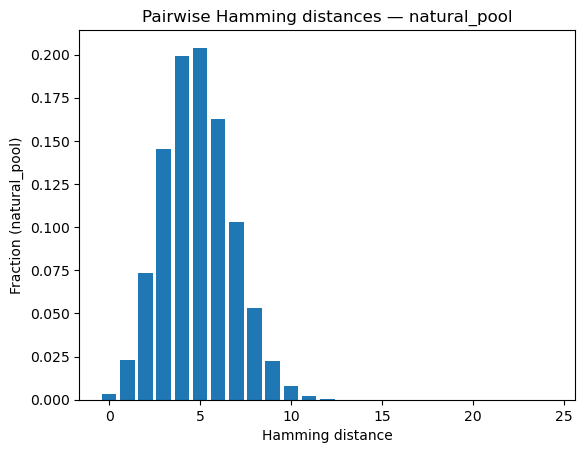

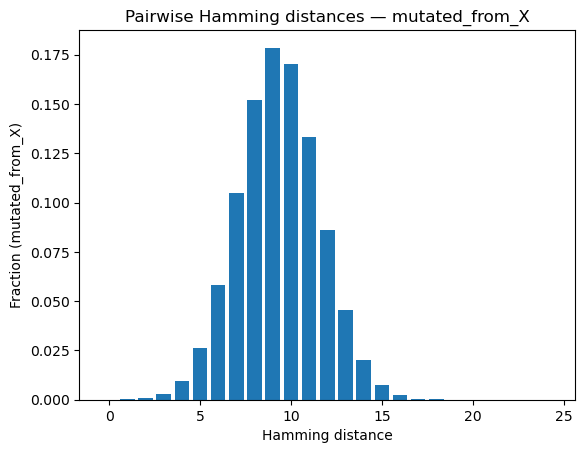

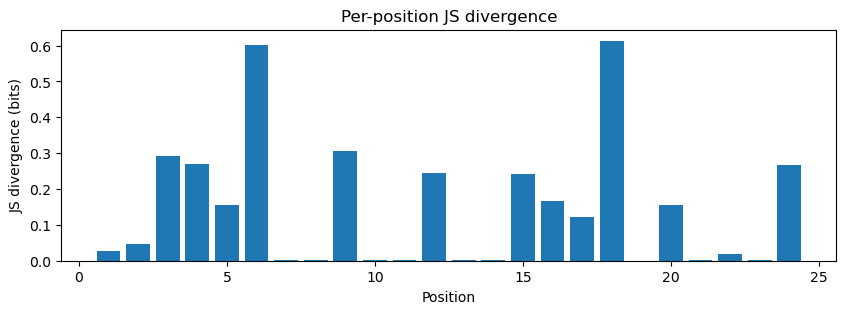


=== DEGENERATE BASE INFORMATION ===
Position 3: 'N' can be ['A', 'C', 'G', 'T']
Position 4: 'W' can be ['A', 'T']
Position 5: 'S' can be ['G', 'C']
Position 9: 'B' can be ['C', 'G', 'T']
Position 12: 'B' can be ['C', 'G', 'T']
Position 15: 'B' can be ['C', 'G', 'T']
Position 16: 'W' can be ['A', 'T']
Position 17: 'S' can be ['G', 'C']
Position 20: 'W' can be ['A', 'T']
Position 24: 'N' can be ['A', 'C', 'G', 'T']


In [12]:
#CDR_1 VALIDATION DEGENERATE
your_sequence = "ATNWSCAGBAGBAGBWSCTWCATN"  # ваша последовательность с вырожденным нуклеотидом B
# Путь к вашему PSSM (тот же, что вы загрузили)
pssm_path = "Downloads/cdr2_nucleotide_frequencies.csv"

# Загрузим PSSM — ожидается формат: строки = A/T/G/C, столбцы = Pos1..Pos24
raw = pd.read_csv(pssm_path)
raw = raw.set_index(raw.columns[0])

# Упорядочим ряды как A,C,G,T (на случай иной капитализации)
row_order = []
for r in ['A','C','G','T']:
    for idx in raw.index:
        if str(idx).upper() == r:
            row_order.append(idx)
            break
raw = raw.loc[row_order]

# Транспонируем к форме (positions x nucleotides)
pssm_df = raw.transpose().reset_index(drop=True)
pssm_df.columns = ['A','C','G','T']
pssm_df = pssm_df.astype(float)
pssm_df.index = range(1, 1 + pssm_df.shape[0])

# Нормализация строк (на случай, если в файле counts)
prob_mat = pssm_df[['A','C','G','T']].to_numpy()
row_sums = prob_mat.sum(axis=1, keepdims=True)
prob_mat = np.divide(prob_mat, row_sums, where=(row_sums!=0))

nt_index = {'A':0,'C':1,'G':2,'T':3}

# Словарь вырожденных нуклеотидов IUPAC
degenerate_bases = {
    'R': ['A', 'G'],  # Purine
    'Y': ['C', 'T'],  # Pyrimidine
    'S': ['G', 'C'],  # Strong
    'W': ['A', 'T'],  # Weak
    'K': ['G', 'T'],  # Keto
    'M': ['A', 'C'],  # Amino
    'B': ['C', 'G', 'T'],  # Not A
    'D': ['A', 'G', 'T'],  # Not C
    'H': ['A', 'C', 'T'],  # Not G
    'V': ['A', 'C', 'G'],  # Not T
    'N': ['A', 'C', 'G', 'T'],  # Any
}

def validate_seq(seq, L):
    seq = seq.upper().strip()
    if len(seq) != L:
        raise ValueError(f"Sequence length {len(seq)} != expected {L}.")
    valid_chars = set('ACGT') | set(degenerate_bases.keys())
    if any(ch not in valid_chars for ch in seq):
        raise ValueError(f"Sequence contains invalid characters. Valid: ACGT{''.join(degenerate_bases.keys())}")
    return seq

def expand_degenerate_base(base):
    """Раскрывает вырожденный нуклеотид в список возможных стандартных нуклеотидов"""
    base = base.upper()
    if base in 'ACGT':
        return [base]
    elif base in degenerate_bases:
        return degenerate_bases[base]
    else:
        raise ValueError(f"Unknown nucleotide: {base}")

def seq_log_likelihood(seq):
    seq = validate_seq(seq, prob_mat.shape[0])
    ll = 0.0
    for i, ch in enumerate(seq):
        possible_bases = expand_degenerate_base(ch)
        # Для вырожденных позиций используем сумму вероятностей всех возможных нуклеотидов
        if len(possible_bases) > 1:
            p_sum = sum(prob_mat[i, nt_index[b]] for b in possible_bases)
            if p_sum <= 0:
                ll += -1e9
            else:
                ll += math.log(p_sum)
        else:
            # Для стандартных нуклеотидов - обычный расчет
            p = prob_mat[i, nt_index[ch]]
            if p <= 0:
                ll += -1e9
            else:
                ll += math.log(p)
    return ll

def per_position_entropy(mat=None):
    if mat is None:
        mat = prob_mat
    ent = -np.sum(np.where(mat>0, mat * np.log2(mat), 0), axis=1)
    return ent

def sample_from_pssm(n_samples=2000):
    L = prob_mat.shape[0]
    samples = []
    for _ in range(n_samples):
        seq = []
        for i in range(L):
            seq.append(random.choices(['A','C','G','T'], weights=prob_mat[i], k=1)[0])
        samples.append(''.join(seq))
    return samples

def mutate_sequence_pool(X, n_samples=2000, mean_mutations=3.0):
    L = prob_mat.shape[0]
    X = validate_seq(X, L)
    samples = []
    for _ in range(n_samples):
        k = int(np.random.poisson(mean_mutations))
        k = min(max(0, k), L)
        seq = list(X)
        if k > 0:
            # Выбираем позиции для мутации (только стандартные нуклеотиды могут мутировать)
            standard_positions = [pos for pos in range(L) if seq[pos] in 'ACGT']
            if standard_positions:
                k = min(k, len(standard_positions))
                positions = random.sample(standard_positions, k)
                for pos in positions:
                    probs = prob_mat[pos].copy()
                    orig_idx = nt_index[seq[pos]]
                    probs[orig_idx] = 0.0
                    s = probs.sum()
                    if s <= 0:
                        choices = [b for b in ['A','C','G','T'] if b != seq[pos]]
                        seq[pos] = random.choice(choices)
                    else:
                        probs = probs / s
                        seq[pos] = random.choices(['A','C','G','T'], weights=probs, k=1)[0]
        samples.append(''.join(seq))
    return samples

def resolve_degenerate_sequence(seq, n_resolutions=100):
    """Генерирует несколько конкретных последовательностей из вырожденной"""
    L = len(seq)
    resolutions = []
    for _ in range(n_resolutions):
        resolved_seq = []
        for base in seq:
            if base in 'ACGT':
                resolved_seq.append(base)
            else:
                possible_bases = expand_degenerate_base(base)
                resolved_seq.append(random.choice(possible_bases))
        resolutions.append(''.join(resolved_seq))
    return resolutions

def pairwise_hamming_distance_matrix(seqs):
    n = len(seqs)
    arr = np.array([list(s) for s in seqs])
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            d = np.count_nonzero(arr[i] != arr[j])
            dists.append(d)
    return np.array(dists)

def per_position_freqs(seqs):
    L = len(seqs[0])
    freqs = np.zeros((L,4))
    for s in seqs:
        for i,ch in enumerate(s):
            freqs[i, ['A','C','G','T'].index(ch)] += 1
    freqs = freqs / freqs.sum(axis=1, keepdims=True)
    return freqs

def js_divergence(p, q):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.where(a>0, a, 1e-12)
        b = np.where(b>0, b, 1e-12)
        return np.sum(a * np.log2(a/b))
    L = p.shape[0]
    js = np.array([0.5*(kl(p[i], m[i]) + kl(q[i], m[i])) for i in range(L)])
    return js, js.mean()

def analyze_sequence(X, N=4000, mean_mutations=3.0, n_degenerate_resolutions=100):
    """
    Анализирует последовательность X (может содержать вырожденные нуклеотиды) относительно PSSM
    """
    
    # Валидация последовательности
    X = validate_seq(X, prob_mat.shape[0])
    
    print(f"Analyzing sequence: {X}")
    print(f"Sequence length: {len(X)}")
    
    # Проверяем наличие вырожденных нуклеотидов
    degenerate_positions = [i for i, base in enumerate(X) if base not in 'ACGT']
    if degenerate_positions:
        print(f"Degenerate bases found at positions: {[pos+1 for pos in degenerate_positions]}")
        print("Generating multiple resolutions for analysis...")
    
    # Генерация пулов последовательностей
    natural_pool = sample_from_pssm(n_samples=N)
    
    # Для вырожденных последовательностей генерируем несколько конкретных вариантов
    if degenerate_positions:
        # Анализ для нескольких разрешений вырожденной последовательности
        resolved_sequences = resolve_degenerate_sequence(X, n_resolutions=n_degenerate_resolutions)
        all_mutated_pools = []
        
        for resolved_seq in resolved_sequences:
            mutated_pool = mutate_sequence_pool(resolved_seq, n_samples=N//n_degenerate_resolutions, 
                                              mean_mutations=mean_mutations)
            all_mutated_pools.extend(mutated_pool)
        
        mutated_pool = all_mutated_pools
    else:
        # Стандартная обработка для невырожденной последовательности
        mutated_pool = mutate_sequence_pool(X, n_samples=N, mean_mutations=mean_mutations)
    
    # Расчет попарных расстояний
    nat_pairwise = pairwise_hamming_distance_matrix(natural_pool)
    mut_pairwise = pairwise_hamming_distance_matrix(mutated_pool)
    
    # Расчет частот и дивергенции
    nat_freqs = per_position_freqs(natural_pool)
    mut_freqs = per_position_freqs(mutated_pool)
    js_per_pos, js_mean = js_divergence(nat_freqs, mut_freqs)
    
    # Вывод результатов
    print("\n=== RESULTS ===")
    print("Sequence used (X):", X)
    print("Log-likelihood under PSSM:", seq_log_likelihood(X))
    print("Mean pairwise Hamming (natural_pool):", nat_pairwise.mean())
    print("Mean pairwise Hamming (mutated_from_X):", mut_pairwise.mean())
    print("Mean per-position JS divergence (bits):", js_mean)
    print("Per-position entropy (bits) mean:", per_position_entropy().mean())
    
    if degenerate_positions:
        print(f"\nNote: Analysis based on {n_degenerate_resolutions} resolutions of degenerate sequence")
    
    # Сохранение гистограммы попарных расстояний как CSV
    bins = list(range(0, prob_mat.shape[0]+2))
    nat_hist, _ = np.histogram(nat_pairwise, bins=bins, density=True)
    mut_hist, _ = np.histogram(mut_pairwise, bins=bins, density=True)
    hdist_df = pd.DataFrame({
        "hamming_distance": range(0, prob_mat.shape[0]+1),
        "natural_frac": np.round(nat_hist,6),
        "mutated_frac": np.round(mut_hist,6)
    })
    hdist_df.to_csv("pssm_pairwise_hamming_hist_CDR2.csv", index=False)
    print("Saved histogram CSV to pssm_pairwise_hamming_hist.csv")
    
    # Графики
    plt.figure()
    plt.bar(range(len(nat_hist)), nat_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (natural_pool)')
    plt.title('Pairwise Hamming distances — natural_pool')
    plt.show()
    
    plt.figure()
    plt.bar(range(len(mut_hist)), mut_hist)
    plt.xlabel('Hamming distance')
    plt.ylabel('Fraction (mutated_from_X)')
    plt.title('Pairwise Hamming distances — mutated_from_X')
    plt.show()
    
    plt.figure(figsize=(10,3))
    plt.bar(range(1, len(js_per_pos)+1), js_per_pos)
    plt.xlabel('Position')
    plt.ylabel('JS divergence (bits)')
    plt.title('Per-position JS divergence')
    plt.show()
    
    return {
        'sequence': X,
        'log_likelihood': seq_log_likelihood(X),
        'mean_hamming_natural': nat_pairwise.mean(),
        'mean_hamming_mutated': mut_pairwise.mean(),
        'js_divergence_mean': js_mean,
        'entropy_mean': per_position_entropy().mean(),
        'degenerate_positions': degenerate_positions
    }



# Запуск анализа
results = analyze_sequence(your_sequence, N=4000, mean_mutations=3.0, n_degenerate_resolutions=100)

# Дополнительная информация о вырожденных нуклеотидах
if results['degenerate_positions']:
    print(f"\n=== DEGENERATE BASE INFORMATION ===")
    for pos in results['degenerate_positions']:
        base = your_sequence[pos]
        possible_bases = degenerate_bases[base]
        print(f"Position {pos+1}: '{base}' can be {possible_bases}")